In [8]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("ibrahimqasimi/global-stock-market-indices-2000-2026")

archivo = os.listdir(path)[0]

df = pd.read_csv(os.path.join(path, archivo))

df.head(10)

,Date,Open,High,Low,Close,Volume,Ticker,Index_Name
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,931800000,^GSPC,S&P 500 (USA)
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,^GSPC,S&P 500 (USA)
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,^GSPC,S&P 500 (USA)
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000,^GSPC,S&P 500 (USA)
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000,^GSPC,S&P 500 (USA)
5,2000-01-10,1441.469971,1464.359985,1441.469971,1457.599976,1064800000,^GSPC,S&P 500 (USA)
6,2000-01-11,1457.599976,1458.660034,1434.420044,1438.560059,1014000000,^GSPC,S&P 500 (USA)
7,2000-01-12,1438.560059,1442.599976,1427.079956,1432.250000,974600000,^GSPC,S&P 500 (USA)
8,2000-01-13,1432.250000,1454.199951,1432.250000,1449.680054,1030400000,^GSPC,S&P 500 (USA)
9,2000-01-14,1449.680054,1473.000000,1449.680054,1465.150024,1085900000,^GSPC,S&P 500 (USA)


# Información sobre columnas, filas y tipo de datos.

In [9]:
df.shape #Pido columnas y filas del dataframe.

df.info() #Pido información del dataframe. Me dice el tipo de dato de cada columna, y si hay valores nulos.   

<class 'pandas.DataFrame'>
RangeIndex: 91648 entries, 0 to 91647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        91648 non-null  str    
 1   Open        91648 non-null  float64
 2   High        91648 non-null  float64
 3   Low         91648 non-null  float64
 4   Close       91648 non-null  float64
 5   Volume      91648 non-null  int64  
 6   Ticker      91648 non-null  str    
 7   Index_Name  91648 non-null  str    
dtypes: float64(4), int64(1), str(3)
memory usage: 5.6 MB


# Estadística descriptiva

In [49]:

df.describe()

,Open,High,Low,Close,Volume
count,91648.000000,91648.000000,91648.000000,91648.000000,9.164800e+04
mean,14531.171788,14633.939295,14421.798165,14530.789782,6.993384e+08
std,20442.283949,20603.290299,20284.019864,20448.092236,1.363019e+09
min,466.570007,472.309998,463.540009,468.760010,0.000000e+00
25%,3449.590088,3472.882446,3421.177490,3450.322571,3.664000e+05
50%,7306.299805,7346.660156,7263.399902,7307.364990,1.057258e+08
75%,16633.877930,16749.185059,16517.895020,16639.857910,7.278742e+08
max,191491.000000,192624.000000,190419.000000,191490.000000,9.397454e+10


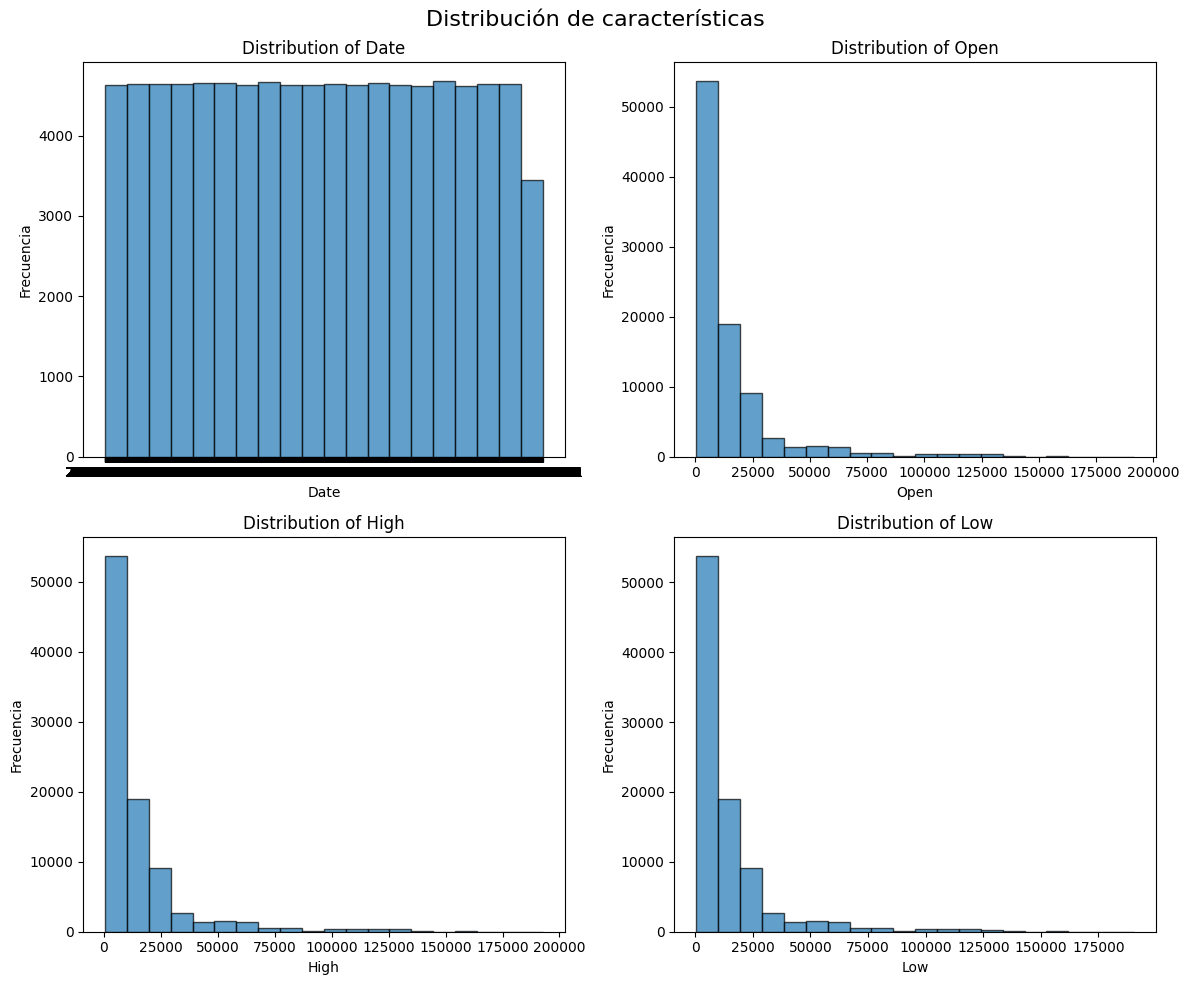

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribución de características', fontsize=16)

features = df.columns

for idx, feature in enumerate(features):
    if idx < 4:
        ax = axes[idx // 2, idx % 2]
        ax.hist(df[feature], bins=20, edgecolor='black', alpha=0.7)
        ax.set_xlabel(feature)
        ax.set_ylabel('Frecuencia')
        ax.set_title(f'Distribution of {feature}')
    else:
        break

plt.tight_layout()
plt.show()

Análisis de valores faltantes 

In [51]:
df.isnull().values.any()

np.False_

Esto nos indica que no hay valores faltantes en todo el dataset. Vamos a optener información sobre los datos mas precisa, que indice esta considerando.

In [66]:
df["Ticker"].nunique()
df["Ticker"].unique()[10:]
df["Ticker"].value_counts().head()

Ticker
^FCHI     6704
^GDAXI    6660
^AXJO     6627
^FTSE     6626
^GSPC     6596
Name: count, dtype: int64

Elegiremos para trabajar "^GSPC" que es el conocido S&P 500. de EE.UU.
Primero le pido me grafique la diferencia entre los valores de cierre y apertura del indice desde el año 2000 al año 2026 que es todo el dataset

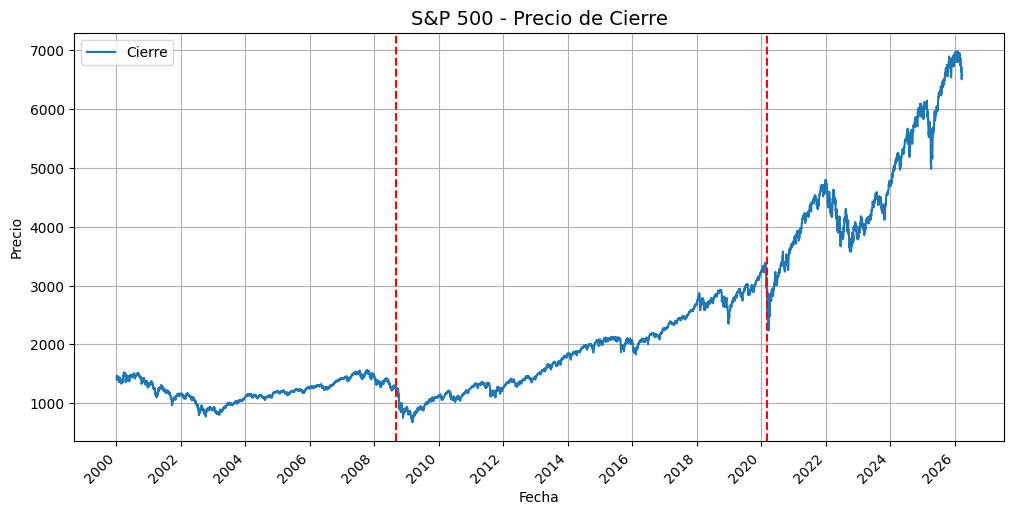

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



# filtrar
sp = df[df["Ticker"] == "^GSPC"].copy()

# fecha
sp["Date"] = pd.to_datetime(sp["Date"])
sp = sp.sort_values("Date")

# usar la fecha como índice (clave para que el eje X sea claro)
sp.set_index("Date", inplace=True)

# gráfico
plt.figure(figsize=(12,6))

ax = sp["Close"].plot(label="Cierre", figsize=(12,6))

ax.xaxis.set_major_locator(mdates.YearLocator(2))  # cada 2 años
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

plt.title("S&P 500 - Precio de Cierre", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.axvline(pd.to_datetime("2008-09-01"), linestyle="--",color='red' , label="Crisis 2008")
plt.axvline(pd.to_datetime("2020-03-01"), linestyle="--", color='red', label="COVID")
plt.show()

Notemos que hay una gran subida del precio de las acciones a partir de 2022, esto coincide con la entrada al mercado de Open Ai y Envidia esta última una empresa dentro del S&P 500. Análicemos con mas detalle ese periodo.

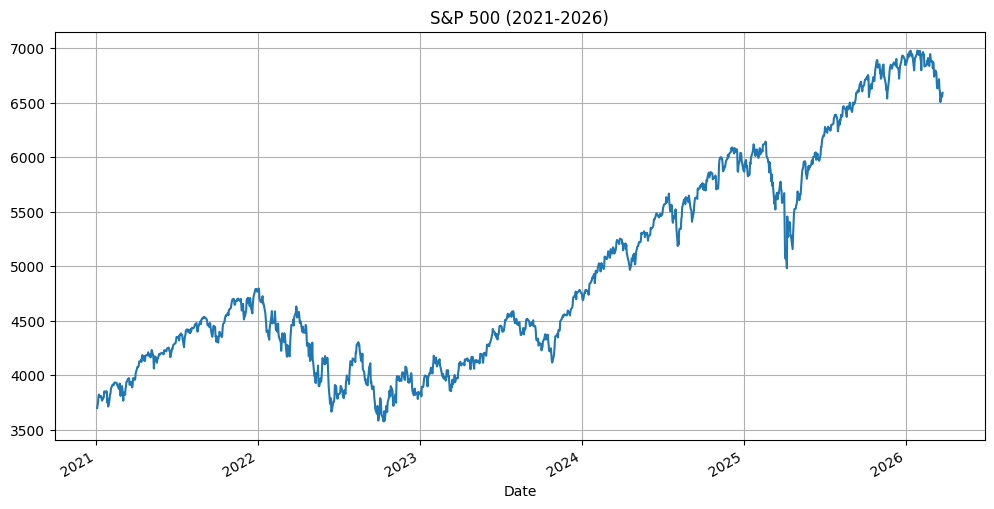

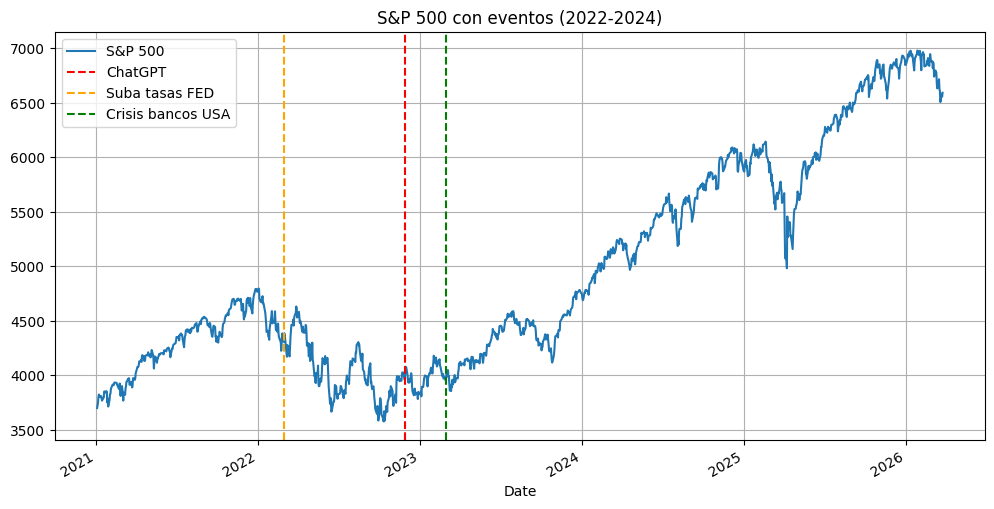

In [99]:
sp_22 = sp.loc["2021":"2026"]

sp_22["Close"].plot(figsize=(12,6))
plt.title("S&P 500 (2021-2026)")
plt.grid(True)
plt.show()
plt.figure(figsize=(12,6))

sp_22["Close"].plot(label="S&P 500")

# Eventos relevantes
plt.axvline(pd.to_datetime("2022-11-30"), linestyle="--", color='red', label="ChatGPT")
plt.axvline(pd.to_datetime("2022-03-01"), linestyle="--", color='orange', label="Suba tasas FED")
plt.axvline(pd.to_datetime("2023-03-01"), linestyle="--", color='green', label="Crisis bancos USA")

plt.legend()
plt.title("S&P 500 con eventos (2022-2024)")
plt.grid(True)
plt.show()

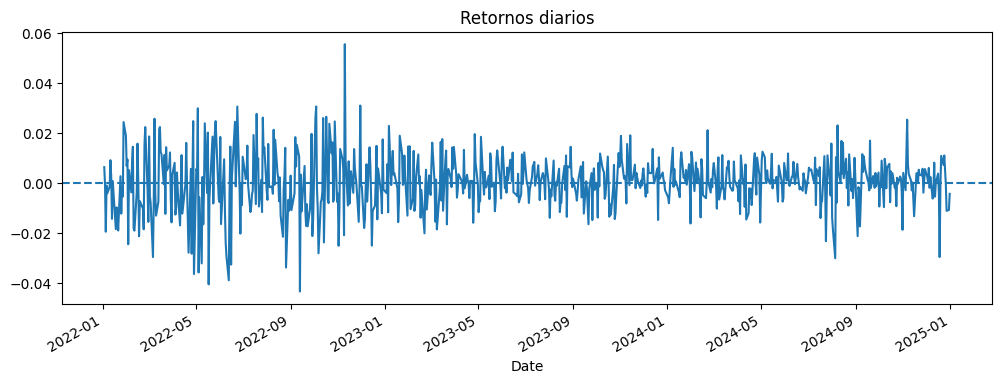

In [97]:
sp["return"] = sp["Close"].pct_change()

sp_22 = sp.loc["2022":"2024"]

sp_22["return"].plot(figsize=(12,4), title="Retornos diarios")
plt.axhline(0, linestyle="--")
plt.show()

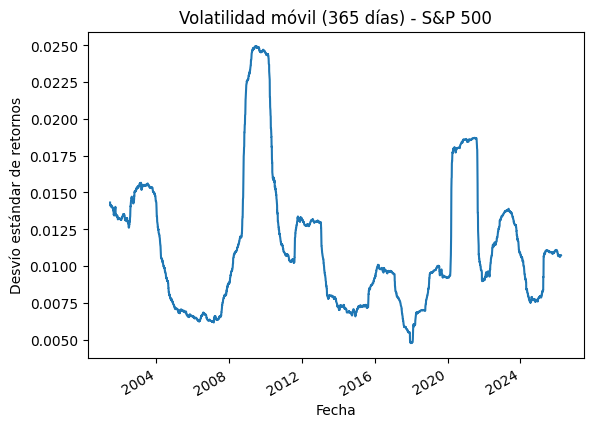

In [100]:
# retornos
sp["return"] = sp["Close"].pct_change()

# volatilidad
sp["volatility_30"] = sp["return"].rolling(365).std()


# gráfico
sp["volatility_30"].plot()

plt.title("Volatilidad móvil (365 días) - S&P 500")
plt.xlabel("Fecha")
plt.ylabel("Desvío estándar de retornos")
plt.show()